In [12]:
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import *
from IPython.display import clear_output
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D

In [13]:
results_folder = "../results/TimeSeries/3D"
create_folder(results_folder)

In [3]:
TYPE_PERC = "bond"
NUM_COLORS = 4
DIM = 3
L = 512
NT = 26000
K = 8.0e-07
RHO = 1.0e-03
P0_LIST = [0.30, 0.70, 1.00]

compute_means_for_folder(
    type_perc=TYPE_PERC,
    num_colors=NUM_COLORS,
    dim=DIM,
    L=L,
    NT=NT,
    k=K,
    rho=RHO,
    p0_list=P0_LIST,
)

[ok] p0=0.30: 100 arquivos agregados
[ok] p0=0.70: 100 arquivos agregados
[ok] p0=1.00: 100 arquivos agregados
[salvo] ../Data/bond_percolation/num_colors_4/dim_3/L_512/NT_constant/NT_26000/k_8.0e-07/rho_1.0000e-03/properties_mean_bundle.json


'../Data/bond_percolation/num_colors_4/dim_3/L_512/NT_constant/NT_26000/k_8.0e-07/rho_1.0000e-03/properties_mean_bundle.json'

In [14]:
def load_bundle(path_json: str | Path):
    path_json = Path(path_json)
    with path_json.open("r") as f:
        bundle = json.load(f)

    # índice rápido: p0_value -> (order -> data_dict)
    p0_index = {}
    for g in bundle["p0_groups"]:
        p0 = float(g["p0_value"])
        orders = { int(o["order_percolation"]): o["data"] for o in g["orders"] }
        p0_index[p0] = orders
    return bundle, p0_index

bundle_path = "../Data/bond_percolation/num_colors_4/dim_3/L_512/NT_constant/NT_26000/k_8.0e-07/rho_1.0000e-03/properties_mean_bundle.json"
bundle, p0_index = load_bundle(bundle_path)
for keys in p0_index[0.3][1]:
    print(keys)

time
pt
nt
Mt
Smax
Ni
chi
stats


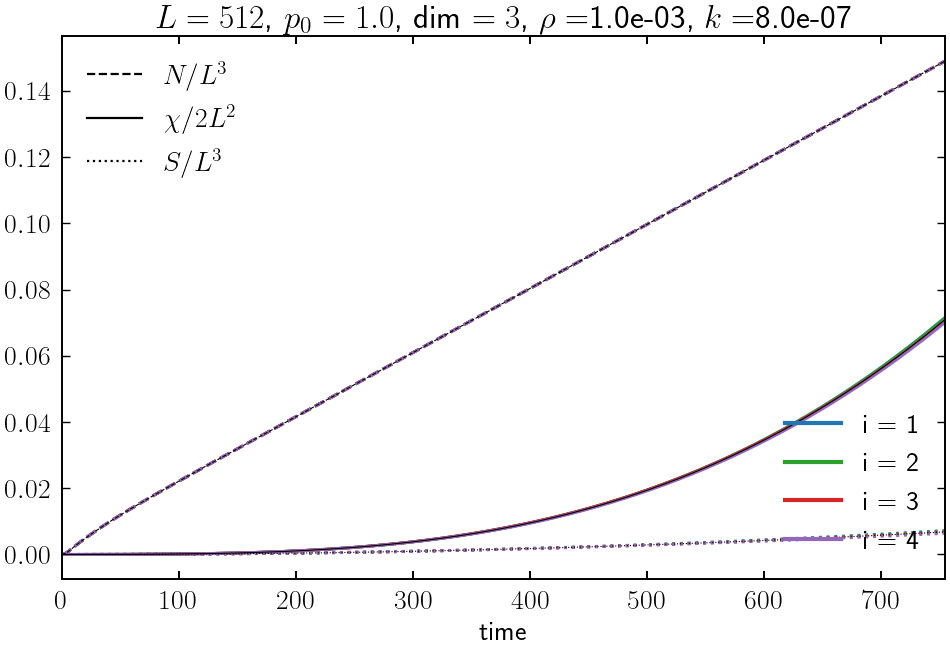

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===== params =====
orders = [1,2,3,4]
p0 = 1.0
L, dim = 512, 3
VOL  = L**dim
AREA = L**(dim-1)


# ===== util =====
def series(key, name):  # pega e já trunca depois
    return np.asarray(p0_index[p0][key][name], dtype=float)

# tamanhos mínimos (garante mesmo comprimento para média/preto)
St  = min(len(series(k,'Smax')) for k in orders)
Nt  = min(len(series(k,'Ni'))   for k in orders)
Ct  = min(len(series(k,'chi'))  for k in orders)
Tt  = min(len(series(k,'time')) for k in orders)
Tmin = min(St, Nt, Ct, Tt)

# ===== plot =====
fig, ax = plt.subplots(figsize=(10,7))

colors = ['C0','C2','C3','C4']   # 4 cores para i=1..4
for j, key in enumerate(orders):
    t   = series(key,'time')[:Tmin]
    S   = series(key,'Smax')[:Tmin] / VOL
    N   = series(key,'Ni')  [:Tmin] / VOL
    chi = series(key,'chi') [:Tmin] / (2*AREA)

    # sanity: S ≤ N sempre
    assert np.all(S <= N), f"S>N para ordem {key}; verifique os dados."

    # linhas coloridas (somente legenda de cores)
    lbl = f"i = {key}"
    ax.plot(t, S,   linestyle=':',  color=colors[j], linewidth=2.1, label=lbl)
    ax.plot(t, N,   linestyle='--', color=colors[j], linewidth=2.1)
    ax.plot(t, chi, linestyle='-',  color=colors[j], linewidth=2.1)

# ===== linhas pretas “guia” (média entre ordens) =====
# empilha e faz média ponto a ponto
t   = series(orders[0],'time')[:Tmin]
S_M = np.mean([series(k,'Smax')[:Tmin]/VOL         for k in orders], axis=0)
N_M = np.mean([series(k,'Ni')  [:Tmin]/VOL         for k in orders], axis=0)
C_M = np.mean([series(k,'chi') [:Tmin]/(2*AREA)    for k in orders], axis=0)

ax.plot(t, N_M, linestyle='--', color='k', linewidth=.8)
ax.plot(t, C_M, linestyle='-',  color='k', linewidth=.8)
ax.plot(t, S_M, linestyle=':',  color='k', linewidth=.8)


# ===== legendas no estilo do artigo =====
style_handles = [
    Line2D([0],[0], color='k', linestyle='--',  linewidth=1.6, label=r'$N/L^{{{}}}$'.format(dim)),
    Line2D([0],[0], color='k', linestyle='-', linewidth=1.6, label=r'$\chi/2L^{{{}}}$'.format(dim-1)),
    Line2D([0],[0], color='k', linestyle=':',  linewidth=1.6, label=r'$S/L^{{{}}}$'.format(dim)),
]
color_handles = [Line2D([0],[0], color=colors[j], linewidth=3, label=f'i = {orders[j]}')
                 for j in range(len(orders))]

leg1 = ax.legend(handles=style_handles, loc='upper left', frameon=False)
ax.add_artist(leg1)
ax.legend(handles=color_handles, loc='lower right', frameon=False, title=None)

# ===== acabamento =====
ax.set_xlabel('time')
ax.set_ylabel('')  # sem label no y, como você pediu
ax.set_xlim(t.min(), t.max())
ax.tick_params(direction='in', top=True, right=True)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.set_title(f"$L = {L}$, $p_0 = {p0}$, dim $= {dim}$, $\\rho = ${RHO:.1e}, $k = ${K:.1e}")
#ax.set_ylim([0.0, 0.25])
plt.tight_layout()

plt.savefig(results_folder + "/EvolutionProperties.pdf")
plt.show()

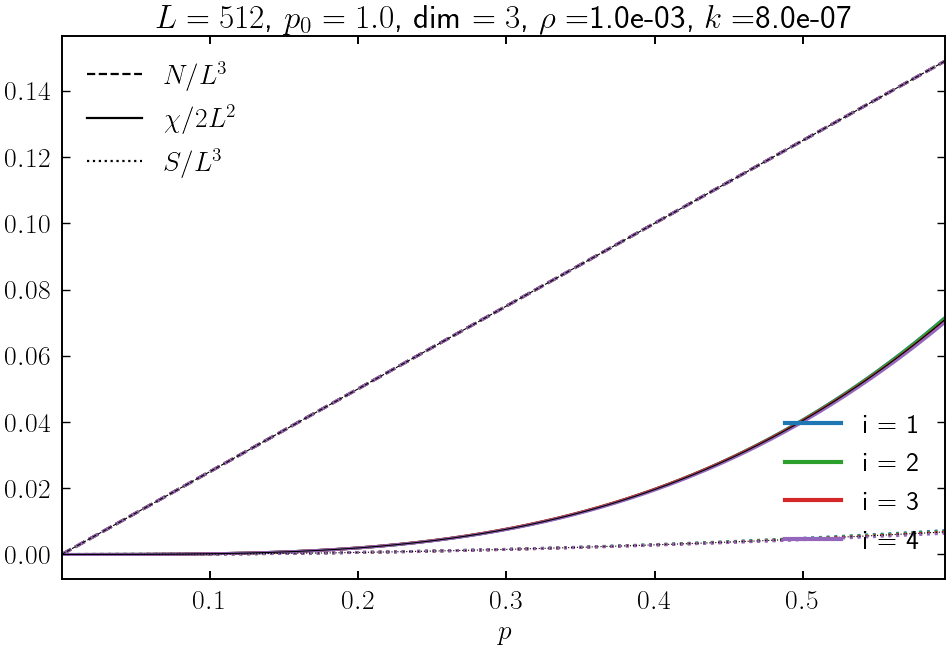

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===== params =====
orders = [1,2,3,4]
p0 = 1.0
L, dim = 512, 3
VOL  = L**dim
AREA = L**(dim-1)

# ===== util =====
def series(key, name):  # pega e já trunca depois
    return np.asarray(p0_index[p0][key][name], dtype=float)

# tamanhos mínimos (garante mesmo comprimento para média/preto)
St  = min(len(series(k,'Smax')) for k in orders)
Nt  = min(len(series(k,'Ni'))   for k in orders)
Ct  = min(len(series(k,'chi'))  for k in orders)
Tt  = min(len(series(k,'time')) for k in orders)
Tmin = min(St, Nt, Ct, Tt)

# ===== p(t) global (soma sobre as cores) =====
# p(t) = (sum_i N_i(t)) / VOL
N_stack = np.stack([series(k, 'Ni')[:Tmin] for k in orders], axis=0)  # shape: (n_orders, Tmin)
p = N_stack.sum(axis=0) / VOL                                        # shape: (Tmin,)

# ===== plot =====
fig, ax = plt.subplots(figsize=(10,7))

colors = ['C0','C2','C3','C4']   # 4 cores para i=1..4

for j, key in enumerate(orders):
    # eixo x agora é p(t), comum a todas as curvas
    x   = p
    S   = series(key,'Smax')[:Tmin] / VOL
    N   = series(key,'Ni')  [:Tmin] / VOL
    chi = series(key,'chi') [:Tmin] / (2*AREA)

    # sanity: S ≤ N sempre
    assert np.all(S <= N), f"S>N para ordem {key}; verifique os dados."

    # linhas coloridas (somente legenda de cores)
    lbl = f"i = {key}"
    ax.plot(x, S,   linestyle=':',  color=colors[j], linewidth=2.1, label=lbl)
    ax.plot(x, N,   linestyle='--', color=colors[j], linewidth=2.1)
    ax.plot(x, chi, linestyle='-',  color=colors[j], linewidth=2.1)

# ===== linhas pretas “guia” (média entre ordens) =====
S_M = np.mean([series(k,'Smax')[:Tmin]/VOL         for k in orders], axis=0)
N_M = np.mean([series(k,'Ni')  [:Tmin]/VOL         for k in orders], axis=0)
C_M = np.mean([series(k,'chi') [:Tmin]/(2*AREA)    for k in orders], axis=0)

ax.plot(p, N_M, linestyle='--', color='k', linewidth=.8)
ax.plot(p, C_M, linestyle='-',  color='k', linewidth=.8)
ax.plot(p, S_M, linestyle=':',  color='k', linewidth=.8)

# ===== legendas no estilo do artigo =====
style_handles = [
    Line2D([0],[0], color='k', linestyle='--', linewidth=1.6, label=r'$N/L^{{{}}}$'.format(dim)),
    Line2D([0],[0], color='k', linestyle='-',  linewidth=1.6, label=r'$\chi/2L^{{{}}}$'.format(dim-1)),
    Line2D([0],[0], color='k', linestyle=':',  linewidth=1.6, label=r'$S/L^{{{}}}$'.format(dim)),
]
color_handles = [Line2D([0],[0], color=colors[j], linewidth=3, label=f'i = {orders[j]}')
                 for j in range(len(orders))]

leg1 = ax.legend(handles=style_handles, loc='upper left', frameon=False)
ax.add_artist(leg1)
ax.legend(handles=color_handles, loc='lower right', frameon=False, title=None)

# ===== acabamento =====
ax.set_xlabel(r'$p$'.format(dim))
ax.set_ylabel('')  # sem label no y
# como p está em [0,1] (fração), os limites ficam naturais:
ax.set_xlim(p.min(), p.max())
ax.tick_params(direction='in', top=True, right=True)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.set_title(f"$L = {L}$, $p_0 = {p0}$, dim $= {dim}$, $\\rho = ${RHO:.1e}, $k = ${K:.1e}")
# ax.set_ylim([0.0, 0.25])

plt.tight_layout()
# plt.savefig(results_folder + "/EvolutionProperties_vs_p.pdf")
plt.show()


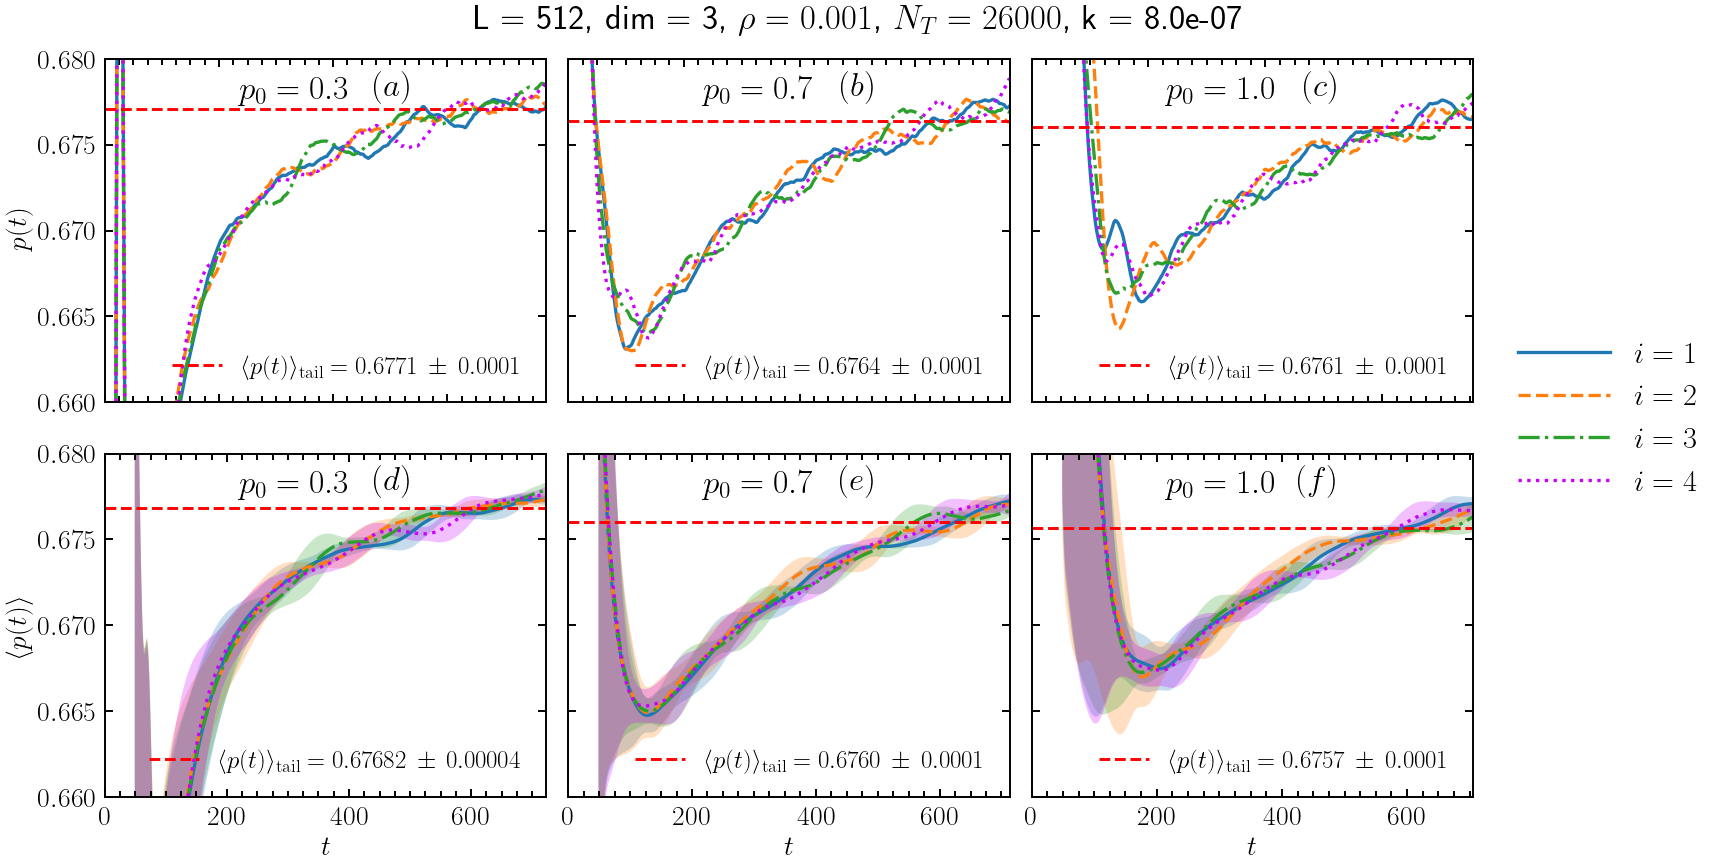

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ================== helpers ==================
def tail_mean(arr, tail_frac=0.3):
    a = np.asarray(arr, dtype=float)
    if a.size == 0: return np.nan
    k = max(1, int(np.floor((1.0 - tail_frac) * a.size)))
    return np.nanmean(a[k:])

def bootstrap_mean_scalar(values, prop, n_boot=20000, ci=0.95, rng=None):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan, np.nan, (np.nan, np.nan)
    rng = np.random.default_rng() if rng is None else rng
    boots = rng.choice(v, size=(n_boot, v.size), replace=True).mean(axis=1)
    mean = v.mean()
    se   = boots.std(ddof=1)
    al   = (1-ci)/2
    lo, hi = np.quantile(boots, [al, 1-al])
    return mean, se, (lo, hi)

def rolling_mean_std(t, y, window: int):
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")
    c  = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))
    mean = (c[window:] - c[:-window]) / window
    var  = (c2[window:] - c2[:-window]) / window - mean**2
    std  = np.sqrt(np.clip(var, 0, None))
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std

# ================== parâmetros ==================
L = 512
dim = 3
k = 8.0e-07
rho = 1.0e-03
NT = 26000

orders     = [1,2,3,4]
p0_list    = [0.3, 0.7, 1.0]
colors     = ["#1f77b4", "#ff7f0e", "#2ca02c", "#cc00ff"]
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
fontsize_ticks = 20
font_labels    = 20
thickness      = 1.4

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95
rng       = np.random.default_rng(12345)

labels_top = ["$(a)$", "$(b)$", "$(c)$"]
labels_bot = ["$(d)$", "$(e)$", "$(f)$"]
major_step = 200
minor_step = 25
window = 100

# ================== figura 2x3 ==================
fig, axes = plt.subplots(2, 3, sharey=True, figsize=(18, 9),
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.15})

common_handles = common_labels = None

# ------------------ LINHA DE CIMA: plot simples ------------------
for col in range(3):
    ax  = axes[0, col]
    p0  = p0_list[col]
    means_per_curve = []

    Tmin = min(len(p0_index[p0][i]['time']) for i in orders)

    for j, i in enumerate(orders):
        t  = np.asarray(p0_index[p0][i]['time'][:Tmin], dtype=float)
        pt = np.asarray(p0_index[p0][i]['pt']  [:Tmin], dtype=float)

        ax.plot(t, pt, ls=linestyles[j], color=colors[j],
                linewidth=1.7*thickness, label=rf"$i = {i}$")

        m_tail = tail_mean(pt, tail_frac=tail_frac)
        if np.isfinite(m_tail): means_per_curve.append(m_tail)

    if col == 0:
        common_handles, common_labels = ax.get_legend_handles_labels()

    # estética (sem label no x e sem números nos ticks do x)
    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                   width=thickness, length=6, pad=6)
    ax.tick_params(axis="x", which="minor", width=thickness, length=4)
    ax.tick_params(axis='x', which='both', labelbottom=False)  # <<< esconde valores dos ticks do x
    ax.set_xlim([0, float(t.max())])
    ax.set_ylim([0.66, 0.68])

    mean_pt, se_pt, _ = bootstrap_mean_scalar(means_per_curve, 'pt', n_boot, ci, rng)
    red = ax.axhline(y=mean_pt, xmin=0, xmax=1.0, color='red', ls='--',
                     lw=1.5*thickness,
                     label=rf"$\langle p(t)\rangle_{{\rm tail}} = {mean_pt:.4f}\,\pm\,{se_pt:.4f}$")
    ax.legend(handles=[red], loc='lower right', frameon=False, fontsize=18)

    ax.text(0.30, 0.95, rf"$p_0 = {p0:.1f}$", transform=ax.transAxes, ha="left", va="top", fontsize=24)
    ax.text(0.70, 0.870, labels_top[col], transform=ax.transAxes, ha="right", va="bottom", fontsize=24)

axes[0,0].set_ylabel(r"$p(t)$", fontsize=font_labels)

# ------------------ LINHA DE BAIXO: média móvel + faixa ±std ------------------
for col in range(3):
    ax  = axes[1, col]
    p0  = p0_list[col]
    means_per_curve = []

    Tmin = min(len(p0_index[p0][i]['time']) for i in orders)

    for j, i in enumerate(orders):
        t  = np.asarray(p0_index[p0][i]['time'][:Tmin], dtype=float)
        pt = np.asarray(p0_index[p0][i]['pt']  [:Tmin], dtype=float)

        w = min(window, len(pt) - 1) if len(pt) > 1 else 1
        tc, mu, sd = rolling_mean_std(t, pt, w)

        ax.plot(tc, mu, ls=linestyles[j], color=colors[j],
                linewidth=1.7*thickness, label=rf"$i = {i}$")
        ax.fill_between(tc, mu - sd, mu + sd, alpha=0.25, color=colors[j], linewidth=0)

        m_tail = tail_mean(mu, tail_frac=tail_frac)
        if np.isfinite(m_tail): means_per_curve.append(m_tail)

    # estética (com label no x e com valores dos ticks)
    ax.set_xlabel("$t$", fontsize=font_labels)   # <<< somente na linha de baixo
    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                   width=thickness, length=6, pad=6)
    ax.tick_params(axis="x", which="minor", width=thickness, length=4)
    ax.set_xlim([0, float(tc.max() if tc.size else 0)])
    ax.set_ylim([0.66, 0.68])

    mean_pt, se_pt, _ = bootstrap_mean_scalar(means_per_curve, 'pt', n_boot, ci, rng)
    if(col==0):
        red = ax.axhline(y=mean_pt, xmin=0, xmax=1.0, color='red', ls='--',
                        lw=1.5*thickness,
                        label=rf"$\langle p(t)\rangle_{{\rm tail}} = {mean_pt:.5f}\,\pm\,{se_pt:.5f}$")
    else:
        red = ax.axhline(y=mean_pt, xmin=0, xmax=1.0, color='red', ls='--',
                lw=1.5*thickness,
                label=rf"$\langle p(t)\rangle_{{\rm tail}} = {mean_pt:.4f}\,\pm\,{se_pt:.4f}$")
   
    ax.legend(handles=[red], loc='lower right', frameon=False, fontsize=18)

    ax.text(0.30, 0.95, rf"$p_0 = {p0:.1f}$", transform=ax.transAxes, ha="left", va="top", fontsize=24)
    ax.text(0.70, 0.870, labels_bot[col], transform=ax.transAxes, ha="right", va="bottom", fontsize=24)

axes[1,0].set_ylabel(r"$\langle p(t) \rangle$", fontsize=font_labels)

# -------- legenda global --------
fig.legend(common_handles, common_labels,
           loc='center left', bbox_to_anchor=(0.85, 0.52),
           frameon=False, ncol=1, fontsize=22, handlelength=3)

# -------- layout / título --------
fig.subplots_adjust(left=0.08, right=0.84, top=0.92, bottom=0.10, wspace=0.18, hspace=0.28)
fig.suptitle(rf"L = {L}, dim = {dim},  $\rho = {rho}$, $N_T = {NT}$, k = {k:.1e}",
             fontsize=25, fontweight="bold", y=0.98)

plt.savefig(results_folder + "/4colors_pt_diff_p0.pdf", bbox_inches="tight")
plt.show()


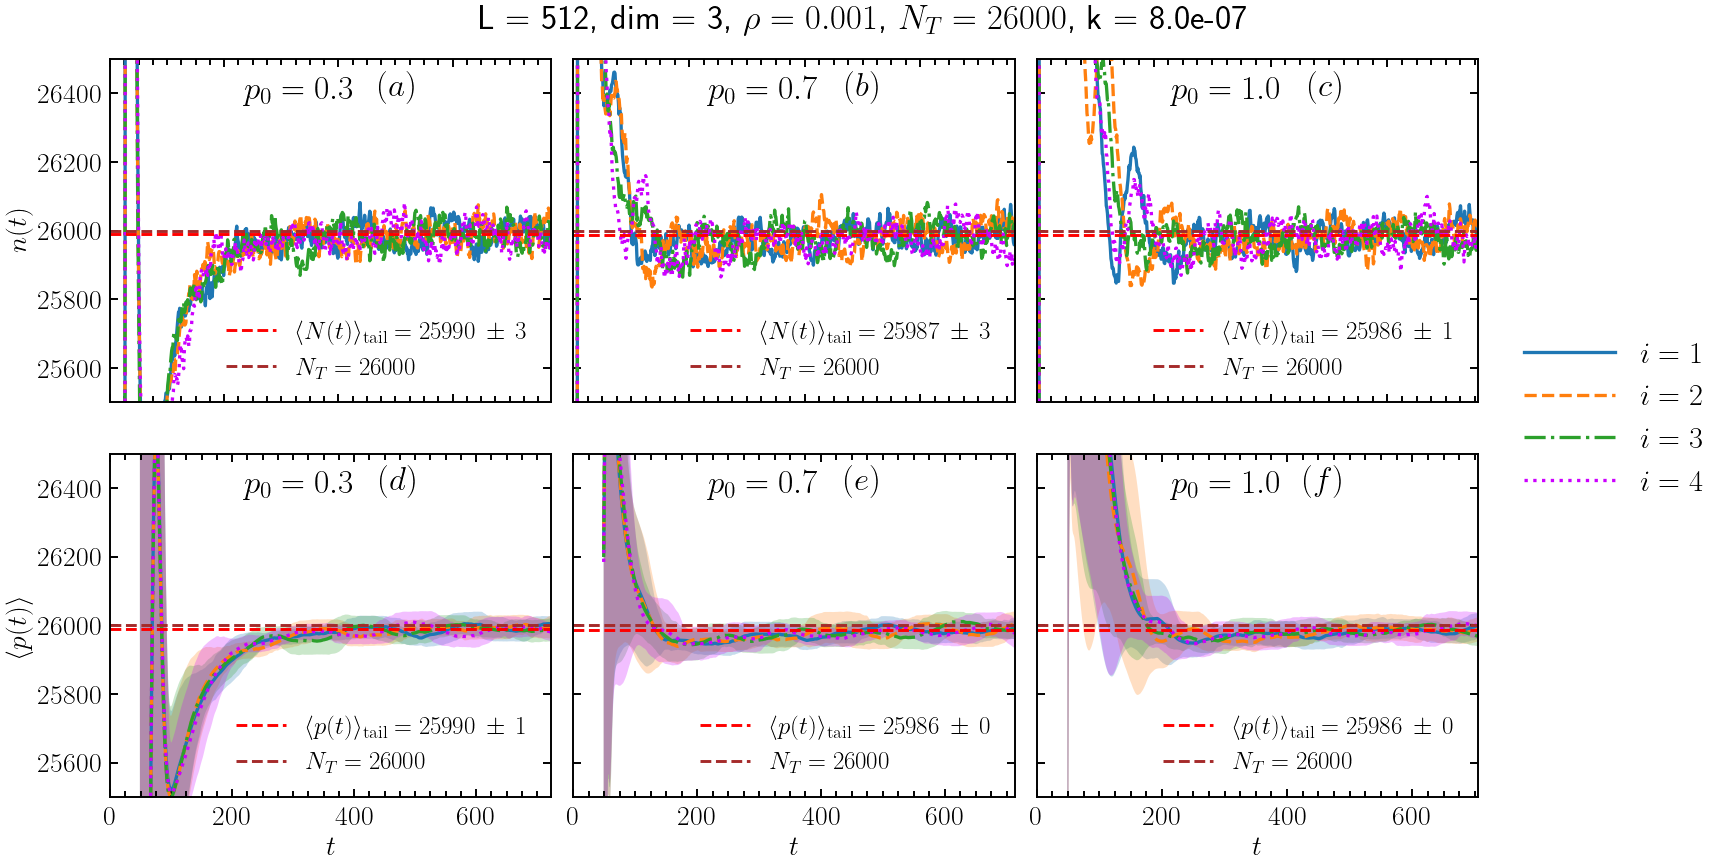

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ================== helpers ==================
def tail_mean(arr, tail_frac=0.3):
    a = np.asarray(arr, dtype=float)
    if a.size == 0: return np.nan
    k = max(1, int(np.floor((1.0 - tail_frac) * a.size)))
    return np.nanmean(a[k:])

def bootstrap_mean_scalar(values, prop, n_boot=20000, ci=0.95, rng=None):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan, np.nan, (np.nan, np.nan)
    rng = np.random.default_rng() if rng is None else rng
    boots = rng.choice(v, size=(n_boot, v.size), replace=True).mean(axis=1)
    mean = v.mean()
    se   = boots.std(ddof=1)
    al   = (1-ci)/2
    lo, hi = np.quantile(boots, [al, 1-al])
    return mean, se, (lo, hi)

def rolling_mean_std(t, y, window: int):
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")
    c  = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))
    mean = (c[window:] - c[:-window]) / window
    var  = (c2[window:] - c2[:-window]) / window - mean**2
    std  = np.sqrt(np.clip(var, 0, None))
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std

# ================== parâmetros ==================
L = 512
dim = 3
k = 8.0e-07
rho = 1.0e-03
NT = 26000

orders     = [1,2,3,4]
p0_list    = [0.3, 0.7, 1.0]
colors     = ["#1f77b4", "#ff7f0e", "#2ca02c", "#cc00ff"]
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
fontsize_ticks = 20
font_labels    = 20
thickness      = 1.4

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95
rng       = np.random.default_rng(12345)

labels_top = ["$(a)$", "$(b)$", "$(c)$"]
labels_bot = ["$(d)$", "$(e)$", "$(f)$"]
major_step = 200
minor_step = 25
window = 100

ymin, ymax = 25500,26500
# ================== figura 2x3 ==================
fig, axes = plt.subplots(2, 3, sharey=True, figsize=(18, 9),
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.15})

common_handles = common_labels = None

# ------------------ LINHA DE CIMA: plot simples ------------------
for col in range(3):
    ax  = axes[0, col]
    p0  = p0_list[col]
    means_per_curve = []

    Tmin = min(len(p0_index[p0][i]['time']) for i in orders)

    for j, i in enumerate(orders):
        t  = np.asarray(p0_index[p0][i]['time'][:Tmin], dtype=float)
        nt = np.asarray(p0_index[p0][i]['nt']  [:Tmin], dtype=float)

        ax.plot(t, nt, ls=linestyles[j], color=colors[j],
                linewidth=1.7*thickness, label=rf"$i = {i}$")

        m_tail = tail_mean(nt, tail_frac=tail_frac)
        if np.isfinite(m_tail): means_per_curve.append(m_tail)

    if col == 0:
        common_handles, common_labels = ax.get_legend_handles_labels()

    # estética (sem label no x e sem números nos ticks do x)
    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                   width=thickness, length=6, pad=6)
    ax.tick_params(axis="x", which="minor", width=thickness, length=4)
    ax.tick_params(axis='x', which='both', labelbottom=False)  # <<< esconde valores dos ticks do x
    ax.set_xlim([0, float(t.max())])
    ax.set_ylim([ymin, ymax])

    mean_nt, se_nt, _ = bootstrap_mean_scalar(means_per_curve, 'nt', n_boot, ci, rng)
    red = ax.axhline(y=mean_nt, xmin=0, xmax=1.0, color='red', ls='--',
                     lw=1.5*thickness,
                     label=rf"$\langle N(t)\rangle_{{\rm tail}} = {int(mean_nt)}\,\pm\,{int(se_nt)}$")
    brown = ax.axhline(y=NT, xmin=0, xmax=1.0, color='brown', ls='--',
                    lw=1.5*thickness,
                    label=rf"$N_T={NT}$")
    ax.legend(handles=[red, brown], loc='lower right', frameon=False, fontsize=18)

    ax.text(0.30, 0.95, rf"$p_0 = {p0:.1f}$", transform=ax.transAxes, ha="left", va="top", fontsize=24)
    ax.text(0.70, 0.870, labels_top[col], transform=ax.transAxes, ha="right", va="bottom", fontsize=24)

axes[0,0].set_ylabel(r"$n(t)$", fontsize=font_labels)

# ------------------ LINHA DE BAIXO: média móvel + faixa ±std ------------------
for col in range(3):
    ax  = axes[1, col]
    p0  = p0_list[col]
    means_per_curve = []

    Tmin = min(len(p0_index[p0][i]['time']) for i in orders)

    for j, i in enumerate(orders):
        t  = np.asarray(p0_index[p0][i]['time'][:Tmin], dtype=float)
        nt = np.asarray(p0_index[p0][i]['nt']  [:Tmin], dtype=float)

        w = min(window, len(nt) - 1) if len(nt) > 1 else 1
        tc, mu, sd = rolling_mean_std(t, nt, w)

        ax.plot(tc, mu, ls=linestyles[j], color=colors[j],
                linewidth=1.7*thickness, label=rf"$i = {i}$")
        ax.fill_between(tc, mu - sd, mu + sd, alpha=0.25, color=colors[j], linewidth=0)

        m_tail = tail_mean(mu, tail_frac=tail_frac)
        if np.isfinite(m_tail): means_per_curve.append(m_tail)

    # estética (com label no x e com valores dos ticks)
    ax.set_xlabel("$t$", fontsize=font_labels)   # <<< somente na linha de baixo
    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                   width=thickness, length=6, pad=6)
    ax.tick_params(axis="x", which="minor", width=thickness, length=4)
    ax.set_xlim([0, float(tc.max() if tc.size else 0)])
    ax.set_ylim([ymin, ymax])

    mean_nt, se_nt, _ = bootstrap_mean_scalar(means_per_curve, 'nt', n_boot, ci, rng)
    
    red = ax.axhline(y=mean_nt, xmin=0, xmax=1.0, color='red', ls='--',
                    lw=1.5*thickness,
                    label=rf"$\langle p(t)\rangle_{{\rm tail}} = {int(mean_nt)}\,\pm\,{int(se_nt)}$")
    brown = ax.axhline(y=NT, xmin=0, xmax=1.0, color='brown', ls='--',
                lw=1.5*thickness,
                label=rf"$N_T={NT}$")
    ax.legend(handles=[red, brown], loc='lower right', frameon=False, fontsize=18)

    ax.text(0.30, 0.95, rf"$p_0 = {p0:.1f}$", transform=ax.transAxes, ha="left", va="top", fontsize=24)
    ax.text(0.70, 0.870, labels_bot[col], transform=ax.transAxes, ha="right", va="bottom", fontsize=24)

axes[1,0].set_ylabel(r"$\langle p(t) \rangle$", fontsize=font_labels)

# -------- legenda global --------
fig.legend(common_handles, common_labels,
           loc='center left', bbox_to_anchor=(0.85, 0.52),
           frameon=False, ncol=1, fontsize=22, handlelength=3)

# -------- layout / título --------
fig.subplots_adjust(left=0.08, right=0.84, top=0.92, bottom=0.10, wspace=0.18, hspace=0.28)
fig.suptitle(rf"L = {L}, dim = {dim},  $\rho = {rho}$, $N_T = {NT}$, k = {k:.1e}",
             fontsize=25, fontweight="bold", y=0.98)

#plt.savefig(results_folder + "/4colors_Nt_diff_p0.pdf", bbox_inches="tight")
plt.show()


In [69]:
import pandas as pd
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 3

# 1) Ler convertendo "Null" para NaN
df_all_3d = pd.read_csv(
    f"../Data/{type_perc}_percolation/all_data_{dim}D.dat",
    sep="\t",
    na_values=["Null", "null", "NaN", "nan", ""]
)

# 2) (opcional) garantir numérico nas colunas de interesse
num_cols = ["rho","p0","order","num_samples","num_sample_perc",
            "pt_mean","pt_erro","nt_mean","nt_erro"]
for c in num_cols:
    if c in df_all_3d.columns:
        df_all_3d[c] = pd.to_numeric(df_all_3d[c], errors="coerce")

# 3) Filtrar linhas SEM NaN em pt_mean e nt_mean
df_clean_3d = df_all_3d.dropna(subset=["pt_mean","nt_mean"]).copy()


# ver somente um range de colunas
df_clean_3d

# Filtrar simulações onde todos percolam

,type_perc,num_colors,dim,L,Nt,k,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro,M_size_mean,M_size_erro,perc_rate
0,bond,2,3,128,1600,0.000010,0.000100,1.0,1,1000,1000,0.386657,0.000051,1603.561339,0.135242,497156.515000,240.366861,1.000
1,bond,2,3,128,1600,0.000010,0.000100,1.0,2,1000,1000,0.386949,0.000050,1602.902285,0.144332,496987.296000,237.071401,1.000
2,bond,2,3,128,1600,0.000010,0.006428,1.0,1,1000,1000,0.387630,0.000052,1603.550766,0.140593,497157.552000,240.854266,1.000
3,bond,2,3,128,1600,0.000010,0.006428,1.0,2,1000,1000,0.387978,0.000051,1602.928416,0.140089,497034.416000,236.592817,1.000
4,bond,2,3,128,1600,0.000010,0.012756,1.0,1,1000,1000,0.388682,0.000052,1603.736659,0.140635,496635.867000,243.137547,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2066,bond,8,3,256,6500,0.000003,0.090218,1.0,3,500,407,1.000000,0.000000,185.542342,4.394476,271949.056511,6263.211721,0.814
2067,bond,8,3,256,6500,0.000003,0.090218,1.0,4,500,200,1.000000,0.000000,158.663874,5.178732,231295.180000,7811.394246,0.400
2068,bond,8,3,256,6500,0.000003,0.090218,1.0,5,500,54,1.000000,0.000000,139.506114,7.815782,198749.148148,10311.238676,0.108
2069,bond,8,3,256,6500,0.000003,0.090218,1.0,6,500,6,1.000000,0.000000,127.276833,17.364504,170804.833333,27765.640166,0.012


In [70]:
df_clean_3d[(df_clean_3d["num_colors"]==4) & (df_clean_3d["rho"]==0.22786)]

,type_perc,num_colors,dim,L,Nt,k,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro,M_size_mean,M_size_erro,perc_rate
616,bond,4,3,128,1600,0.000010,0.22786,1.0,1,1000,521,1.0,0.0,70.371699,1.130821,53787.445298,950.874537,0.521
617,bond,4,3,128,1600,0.000010,0.22786,1.0,2,1000,82,1.0,0.0,52.952652,2.339706,42859.365854,1819.045160,0.082
618,bond,4,3,128,1600,0.000010,0.22786,1.0,3,1000,7,1.0,0.0,43.426479,7.512191,33958.142857,3456.837623,0.007
936,bond,4,3,256,6500,0.000003,0.22786,1.0,1,500,184,1.0,0.0,138.477058,3.848899,263174.489130,8469.009537,0.368
937,bond,4,3,256,6500,0.000003,0.22786,1.0,2,500,15,1.0,0.0,111.406187,11.149577,216823.266667,22287.271856,0.030


Valor de rho_max válido: 0.22469


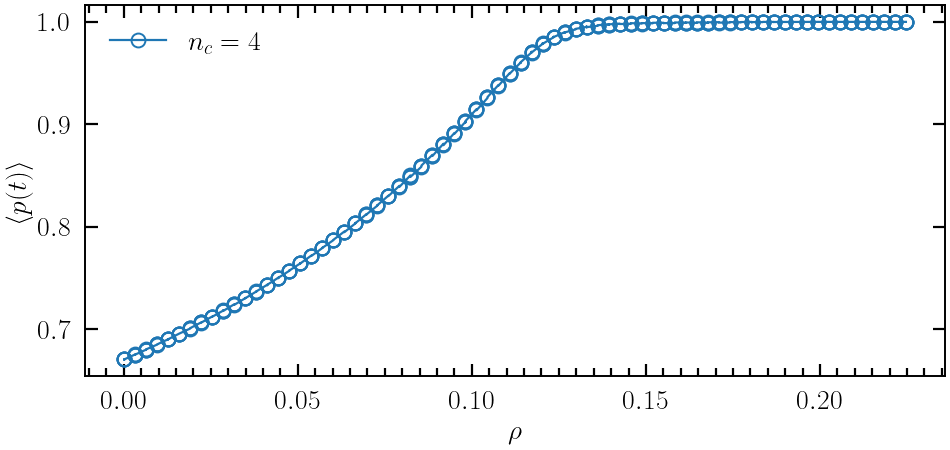

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
n_colors = [4]
fig, ax = plt.subplots(figsize=(10, 5))
for num_colors in n_colors:
    # ================== 1) Seleção, limpeza e reamostragem ==================
    # Filtrar os dados para num_colors = 4
    df_plot = df_clean_3d[(df_clean_3d["num_colors"] == num_colors) & (df_clean_3d["L"]==256)].copy()

    # Garantir que as colunas necessárias sejam numéricas
    for c in ["rho", "pt_mean", "pt_erro"]:
        if c in df_plot.columns:
            df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce")

    # Remover valores nulos
    df_plot = df_plot.dropna(subset=["rho", "pt_mean"]).sort_values("rho")

    # ================== 2) Encontrar o valor máximo de rho válido para todos os orders ==================
    # Inicializar o valor de rho_max
    rho_max = 0.0

    # Verificar para cada valor de rho até onde existem dados válidos para cada order
    for rho in np.unique(df_plot["rho"]):
        # Filtrar os dados para o rho específico
        df_rho = df_plot[df_plot["rho"] == rho]
        
        # Verificar se todos os orders (1, 2, 3, 4) têm dados válidos
        valid_orders = df_rho["order"].unique()
        
        if all(order in valid_orders for order in [1, 2, 3, 4]):
            rho_max = rho

    # Mostrar o valor de rho_max encontrado
    print(f"Valor de rho_max válido: {rho_max}")

    # ================== 3) Plot ==================
    fontsize_ticks = 20
    font_labels     = 20
    ms              = 10
    thickness       = 1.6
    edge_width      = 1.4
    color_main      = "C0"   # cor da curva

    

    # Filtrar os dados para rho <= rho_max
    df_filtered = df_plot[df_plot["rho"] <= rho_max]

    # Plotar a curva para order = 1
    ax.plot(
        df_filtered["rho"], df_filtered["pt_mean"], "o-",
        lw=thickness,
        ms=ms,
        markerfacecolor='none',          # marcador SEM preenchimento
        markeredgecolor=color_main,      # contorno do marcador
        markeredgewidth=edge_width,
        label=f"$n_c = {num_colors}$",
        zorder=2
    )

# Labels, limites, grade
ax.set_xlabel(r"$\rho$", fontsize=font_labels)
ax.set_ylabel(r"$\langle p(t) \rangle$", fontsize=font_labels)

# Ticks principais e secundários
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))
ax.yaxis.set_major_locator(MultipleLocator(0.1))

ax.tick_params(axis="both", which="major",
               labelsize=fontsize_ticks, width=thickness, length=9, pad=10)
ax.tick_params(axis="x", which="minor", width=thickness, length=6)

# Legenda
ax.legend(frameon=False)

plt.tight_layout()

# Salvar (opcional): se 'savepath' existir, salva; caso contrário, só mostra
try:
    plt.savefig(results_folder + "/p_mean_X_rho_order_1.pdf", dpi=300)
except NameError:
    pass

plt.show()
